In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve


In [2]:
processed_dir = Path("../data/processed")
figures_dir = Path("../figures")
results_dir = Path("../results")

figures_dir.mkdir(parents=True, exist_ok=True)
results_dir.mkdir(parents=True, exist_ok=True)


In [3]:
heart_final = pd.read_csv(processed_dir / "heart_final.csv")
train_data = heart_final[heart_final["split"] == "train"].copy()
test_data = heart_final[heart_final["split"] == "test"].copy()

X_train = train_data.drop(columns=["target", "split"])
y_train = train_data["target"]
X_test = test_data.drop(columns=["target", "split"])
y_test = test_data["target"]


In [4]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
depth_values = range(1, 16)
cv_results = []

for depth in depth_values:
    model = DecisionTreeClassifier(max_depth=depth, random_state=42, class_weight="balanced")
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="accuracy")
    cv_results.append({
        "max_depth": depth,
        "cv_accuracy_mean": scores.mean(),
        "cv_accuracy_std": scores.std()
    })

cv_results = pd.DataFrame(cv_results)
cv_results


,max_depth,cv_accuracy_mean,cv_accuracy_std
0,1,0.759542,0.020936
1,2,0.758191,0.022537
2,3,0.740449,0.032307
3,4,0.756821,0.048406
4,5,0.741874,0.036558
5,6,0.736431,0.044467
6,7,0.745928,0.036879
7,8,0.729592,0.033361
8,9,0.730989,0.033394
9,10,0.729610,0.040277


In [5]:
best_depth = int(cv_results.sort_values("cv_accuracy_mean", ascending=False).iloc[0]["max_depth"])
best_cv_mean = cv_results.loc[cv_results["max_depth"] == best_depth, "cv_accuracy_mean"].iloc[0]
best_cv_std = cv_results.loc[cv_results["max_depth"] == best_depth, "cv_accuracy_std"].iloc[0]

best_depth, best_cv_mean, best_cv_std


(1, np.float64(0.7595421952564809), np.float64(0.020936086560964195))

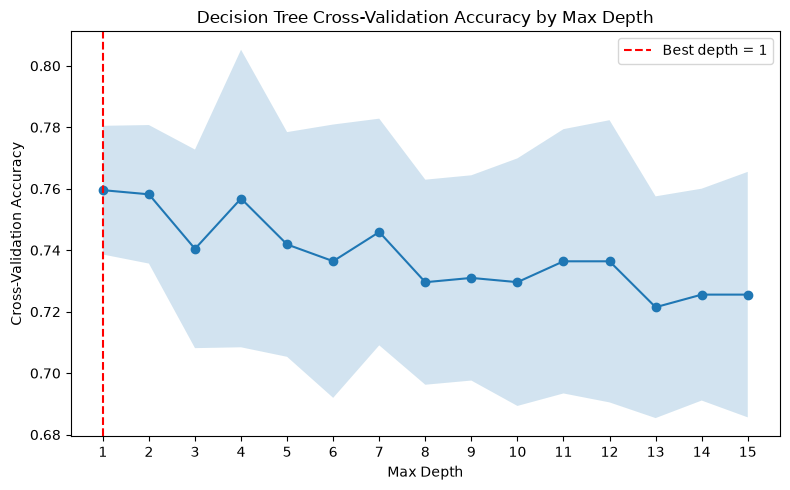

In [6]:
plt.figure(figsize=(8, 5))
plt.plot(cv_results["max_depth"], cv_results["cv_accuracy_mean"], marker="o")
plt.fill_between(
    cv_results["max_depth"],
    cv_results["cv_accuracy_mean"] - cv_results["cv_accuracy_std"],
    cv_results["cv_accuracy_mean"] + cv_results["cv_accuracy_std"],
    alpha=0.2
)
plt.axvline(best_depth, color="red", linestyle="--", label=f"Best depth = {best_depth}")
plt.title("Decision Tree Cross-Validation Accuracy by Max Depth")
plt.xlabel("Max Depth")
plt.ylabel("Cross-Validation Accuracy")
plt.xticks(list(depth_values))
plt.legend()
plt.tight_layout()
plt.savefig(figures_dir / "decision_tree_accuracy_vs_depth.png", dpi=300)
plt.show()


In [7]:
tree_model = DecisionTreeClassifier(max_depth=best_depth, random_state=42, class_weight="balanced")
tree_model.fit(X_train, y_train)

y_pred = tree_model.predict(X_test)
y_proba = tree_model.predict_proba(X_test)[:, 1]


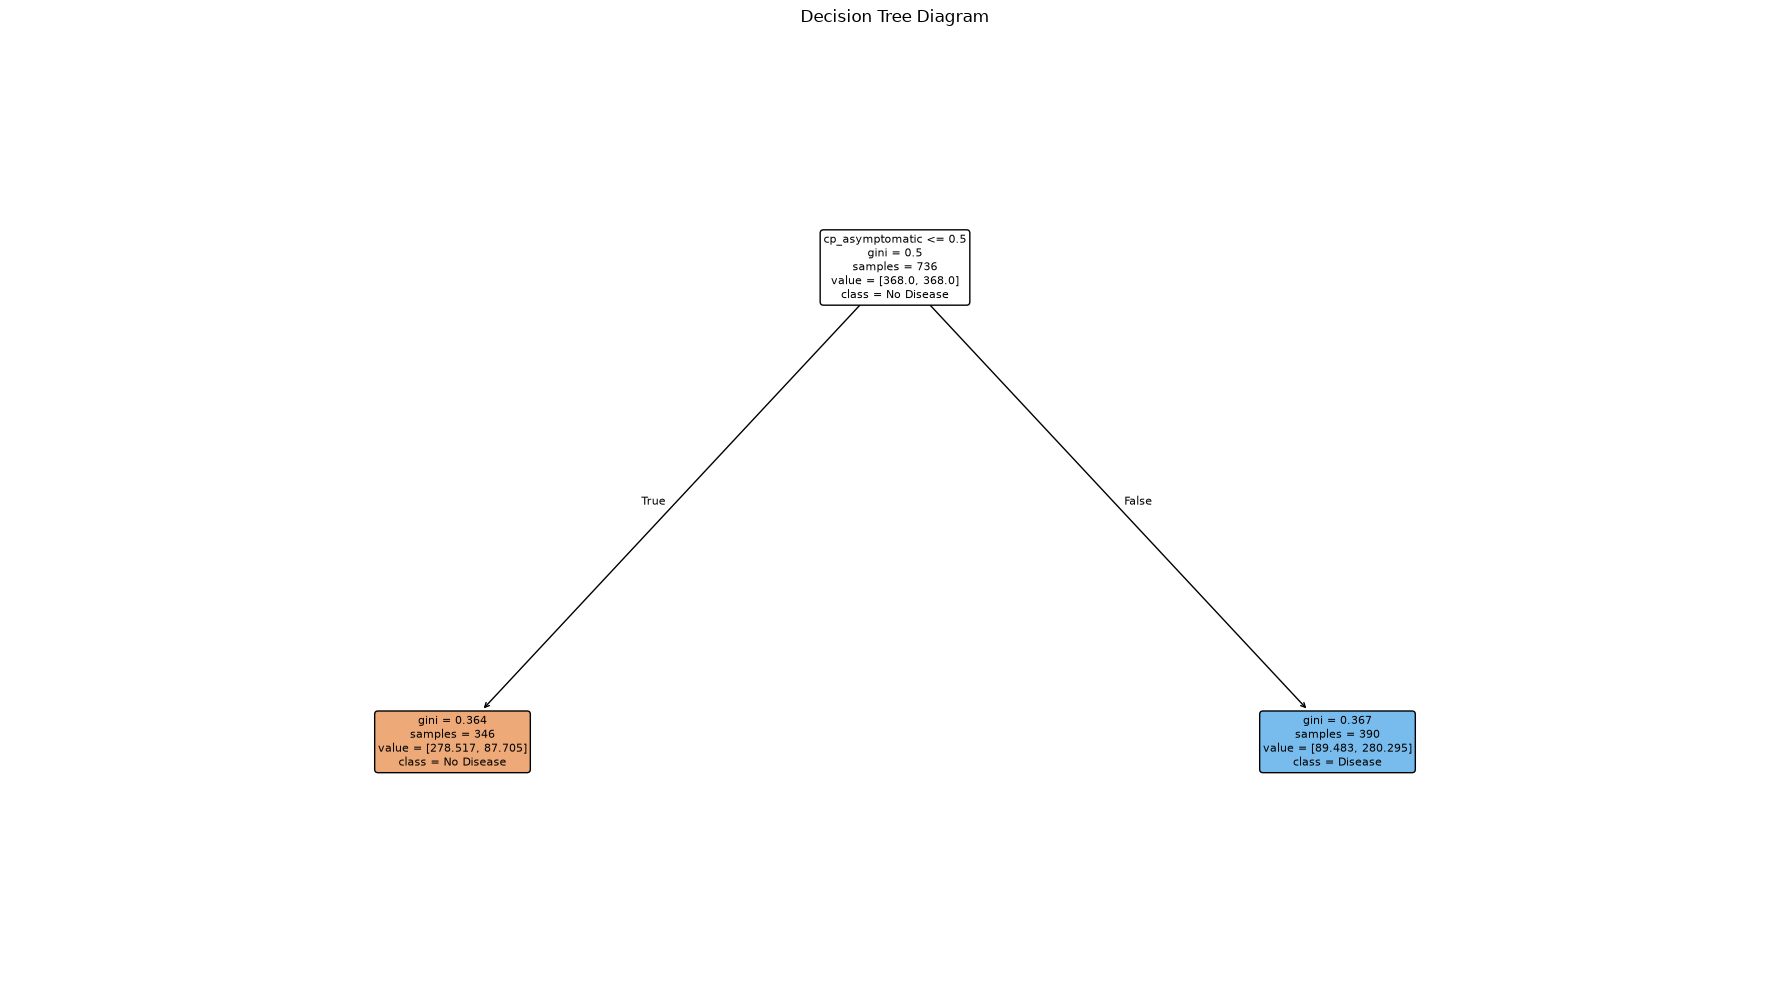

In [8]:
plt.figure(figsize=(18, 10))
plot_tree(tree_model, feature_names=X_train.columns, class_names=["No Disease", "Disease"], filled=True, rounded=True, max_depth=3, fontsize=8)
plt.title("Decision Tree Diagram")
plt.tight_layout()
plt.savefig(figures_dir / "decision_tree_diagram.png", dpi=300)
plt.show()


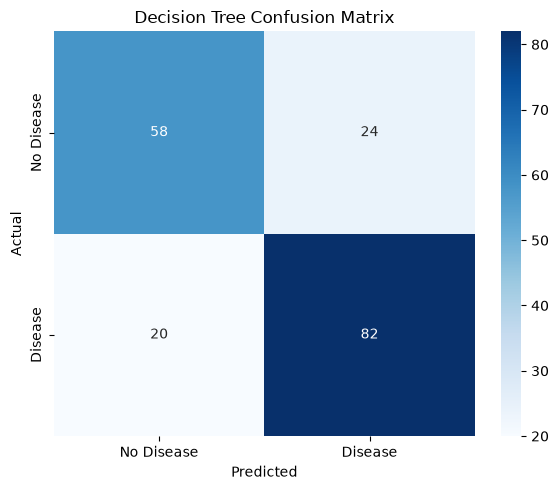

In [9]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["No Disease", "Disease"], yticklabels=["No Disease", "Disease"])
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig(figures_dir / "confusion_matrix_tree.png", dpi=300)
plt.show()


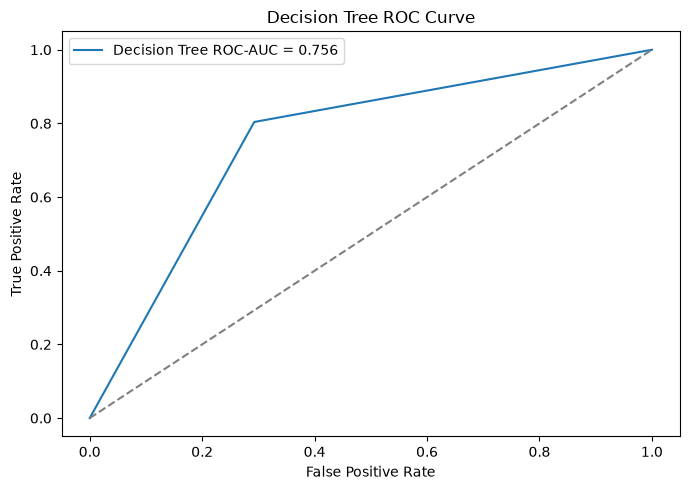

In [10]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"Decision Tree ROC-AUC = {auc_score:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.title("Decision Tree ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.savefig(figures_dir / "roc_curve_tree.png", dpi=300)
plt.show()


In [11]:
feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": tree_model.feature_importances_
}).sort_values("importance", ascending=False)
feature_importance.head(15)


,feature,importance
11,cp_asymptomatic,1.0
1,trestbps,0.0
0,age,0.0
3,thalch,0.0
4,oldpeak,0.0
5,sex_female,0.0
6,sex_male,0.0
7,dataset_cleveland,0.0
8,dataset_hungary,0.0
9,dataset_switzerland,0.0


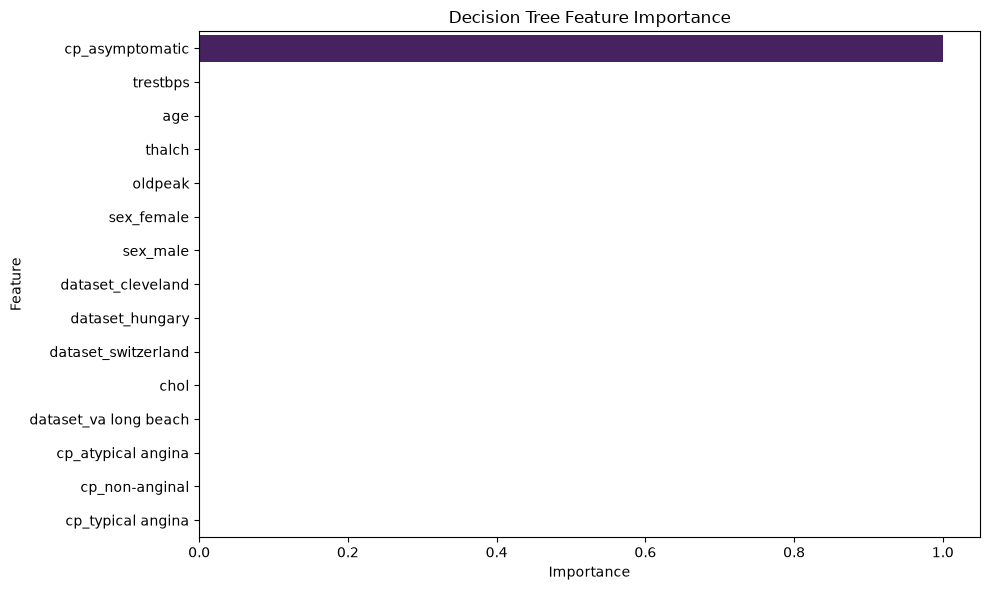

In [12]:
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance.head(15), x="importance", y="feature", hue="feature", legend=False, palette="viridis")
plt.title("Decision Tree Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig(figures_dir / "decision_tree_feature_importance.png", dpi=300)
plt.show()


In [13]:
decision_tree_metrics = pd.DataFrame([{
    "model": "Decision Tree",
    "best_max_depth": best_depth,
    "accuracy": accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred),
    "recall": recall_score(y_test, y_pred),
    "f1": f1_score(y_test, y_pred),
    "roc_auc": auc_score,
    "cv_mean": best_cv_mean,
    "cv_std": best_cv_std
}])

roc_data = pd.DataFrame({"model": "Decision Tree", "fpr": fpr, "tpr": tpr})
decision_tree_metrics


,model,best_max_depth,accuracy,precision,recall,f1,roc_auc,cv_mean,cv_std
0,Decision Tree,1,0.76087,0.773585,0.803922,0.788462,0.755619,0.759542,0.020936


In [14]:
decision_tree_metrics.to_csv(results_dir / "decision_tree_metrics.csv", index=False)
cv_results.to_csv(results_dir / "decision_tree_cv_results.csv", index=False)
roc_data.to_csv(results_dir / "decision_tree_roc_curve.csv", index=False)
feature_importance.to_csv(results_dir / "decision_tree_feature_importance.csv", index=False)
